# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library dasar untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library dari scikit-learn untuk preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Mengabaikan warning agar output notebook terlihat rapi
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Menggunakan raw URL dari public dataset Titanic
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# Memuat dataset ke dalam Pandas DataFrame
df = pd.read_csv(url)

# Menampilkan 5 baris pertama untuk memastikan data termuat dengan benar
print("5 Baris Pertama Dataset:")
display(df.head())

# Mengetahui dimensi data (baris, kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris dan {df.shape[1]} kolom.")

5 Baris Pertama Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dimensi dataset: 891 baris dan 12 kolom.


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
--------------------------------------------------

Jumlah Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch           

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


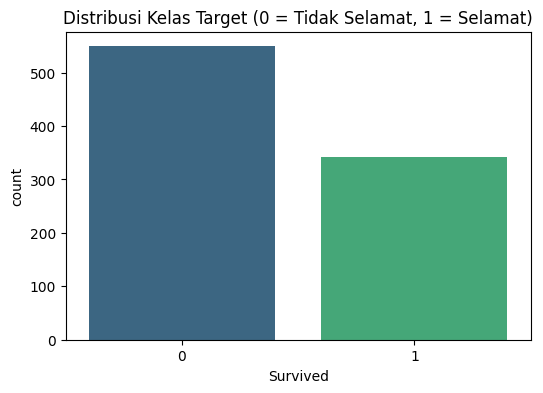

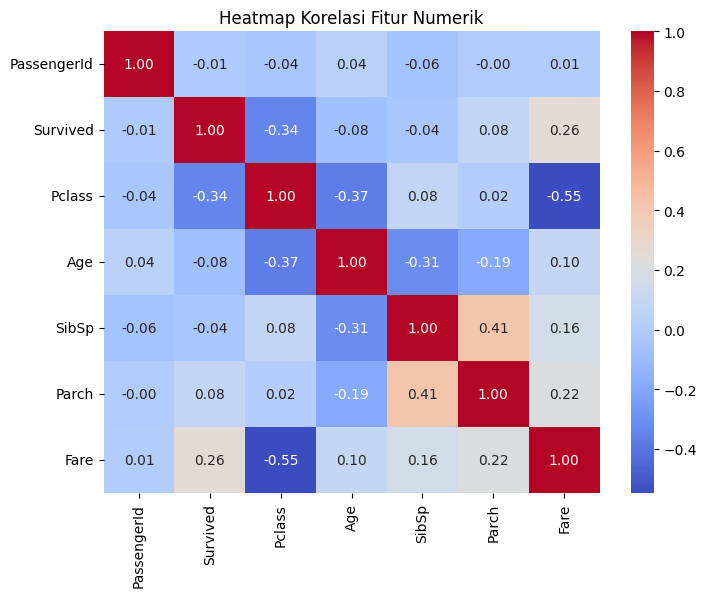

In [3]:
# 1. Menampilkan informasi tipe data dan jumlah non-null
print("Informasi Dataset:\n")
df.info()
print("-" * 50)

# 2. Mengecek jumlah missing values di setiap kolom
print("\nJumlah Missing Values:")
print(df.isnull().sum())
print("-" * 50)

# 3. Menampilkan statistik deskriptif untuk kolom numerik
print("\nStatistik Deskriptif:")
display(df.describe())

# 4. Visualisasi sederhana: Distribusi Target (Survived)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived', palette='viridis')
plt.title('Distribusi Kelas Target (0 = Tidak Selamat, 1 = Selamat)')
plt.show()

# 5. Visualisasi: Korelasi antar fitur numerik
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Membuat salinan data agar data asli tidak berubah
df_clean = df.copy()

# 1. Menghapus kolom yang tidak relevan untuk pemodelan
# PassengerId, Name, Ticket, dan Cabin (karena terlalu banyak missing value) dihapus.
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean.drop(columns=cols_to_drop, inplace=True)

# 2. Menangani Data Kosong (Missing Values)
# Mengisi nilai kosong pada 'Age' dengan nilai median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
# Mengisi nilai kosong pada 'Embarked' dengan modus (nilai yang paling sering muncul)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Menghapus Data Duplikat (jika ada)
df_clean.drop_duplicates(inplace=True)

# 4. Encoding Data Kategorikal
# Mengubah 'Sex' (male/female) menjadi angka 0 dan 1
label_encoder = LabelEncoder()
df_clean['Sex'] = label_encoder.fit_transform(df_clean['Sex'])

# Mengubah 'Embarked' (C, Q, S) menggunakan One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)
# Ubah boolean dari get_dummies menjadi integer (0 dan 1)
for col in df_clean.columns:
    if df_clean[col].dtype == bool:
        df_clean[col] = df_clean[col].astype(int)

# 5. Normalisasi/Standarisasi Fitur Numerik
# Kita akan menstandarisasi kolom 'Age' dan 'Fare' agar memiliki skala yang sama
scaler = StandardScaler()
num_cols = ['Age', 'Fare']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

# Menampilkan hasil akhir data yang sudah diproses
print("Data setelah Preprocessing:")
display(df_clean.head())

# 6. Menyimpan Data Bersih
# Data ini yang akan digunakan di Kriteria selanjutnya (modelling.py / CI/CD)
output_path = 'data_preprocessing.csv'
df_clean.to_csv(output_path, index=False)
print(f"\nDataset bersih berhasil disimpan dengan nama: '{output_path}'")

Data setelah Preprocessing:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,-0.551060,1,0,-0.527515,0,1
1,1,1,0,0.611945,1,0,0.695086,0,0
2,1,3,0,-0.260308,0,0,-0.514627,0,1
3,1,1,0,0.393881,1,0,0.347909,0,1
4,0,3,1,0.393881,0,0,-0.512240,0,1



Dataset bersih berhasil disimpan dengan nama: 'data_preprocessing.csv'
